# 活笔记：TFLN 慢光色散器件
**打开即渲染**：本文本格渲染公式与文字，代码格可直接运行，运行结果（图、数值）内嵌保存在笔记里。随讨论不断生长。

学习背景：已有脉冲压缩 / SAR 基础；正在补 Level 0 第 2–3 项（色散来源、耦合模理论）。

## 学习地图：按依赖关系由浅入深（2026-09-19 重排）
> 原编号保留（交叉引用安全）；顺序按"前者是后者的前提"组织。⭐ = 对话沉淀新增。

**第一部分 · 语言与公理**（读 20 分钟）
§0 组织公理 + 符号表 → §1 色散的三种来源 → §2 设计目标一句话

**第二部分 · 为什么是光栅**（核心物理，读 40 分钟 + 动手 1 小时）
§7 五层推导（为何有色散）→ §8 本征 β± 推导 → ⭐§14 对话沉淀 I（慢光区/带vs台阶/两个regime/带内能量）→ §3 均匀光栅解析模型 + 仿真 + 结果解读

**第三部分 · 能量与渐近**（仿真深入，各 30 分钟）
§12 被抵消的反向光去哪了（内部功率交换）→ §13 从 1 个周期到能带（N 演化）→ ⭐§15 对话沉淀 II（单元→能带）

**第四部分 · 器件与系统**（项目层）
§4 啁啾光栅 + 仿真 + 结果（含有效性判据）→ §5 文献对标 → §10 收发共用 τ(λ) 构想 → §6 课题组接口

**第五部分 · 外围**
§11 前沿调研 → §9 学习清单 → Q: 待回答

依赖链一句话：**n_g(ω) 的图像（§0/§7/§8）→ 均匀光栅的 τ 鼓包（§3）→ 鼓包的物理拆解（§12/§13/§14）→ 把鼓包拉成线（§4）→ 用线与激光器组成系统（§10）**。

---\n\n# 第一部分 · 语言与公理

## 0. 组织公理（2026-09-10）
本项目的所有物理量都是群折射率 $n_g$ 或其对频率的导数：

| 关心的量 | 表达式 | 说明 |
|---|---|---|
| 调制效率 | $\Delta\phi \propto n_g L$ | 行波相位调制器，$V_\pi L \propto 1/n_g$ |
| 群延迟 | $\tau(\omega) = n_g L / c$ | ripple 是 $\tau(\omega)$ 的抖动 |
| GVD | $\beta_2 = \dfrac{dn_g}{d\omega} = \dfrac{d^2 n}{d\omega^2}$ | 色散的物理本质 |
| 色散（器件规格） | $D = \dfrac{d\tau}{d\lambda} = -\dfrac{2\pi c}{\lambda^2}\,\beta_2$ | 系统语言与物理语言的互译 |
| 传播损耗惩罚 | $\alpha \propto n_g$（散射损耗标度） | 慢光的代价之一 |
| 可用带宽 | $\Delta\omega \cdot \tau \sim$ 常数 | 延迟-带宽积约束 |

**关键区分**：相折射率 $n$（LN ≈ 2.2）决定模式分布与布拉格条件 $\lambda_B = 2 n_{\rm eff}\Lambda$；群折射率 $n_g$ 决定包络速度与相互作用时间——本项目的主角。

慢光与大色散是同一物理（光子带结构的频率依赖性）的两个表现：带边附近 $n_g$ 巨大 → 慢光（调制增强）；$n_g$ 随 $\omega$ 剧变 → 大 GVD（目标功能）。

**符号表（本节及全篇通用）**：

| 符号 | 名称 | 单位 | 含义 |
|---|---|---|---|
| $n$ | 相折射率 | 无量纲 | 光场（相位）的折射率，决定模式分布与布拉格条件 |
| $n_g$ | 群折射率 | 无量纲 | 光包络（脉冲）的等效折射率，$n_g = n + \omega\,dn/d\omega$ |
| $n_{\rm eff}$ | 有效折射率 | 无量纲 | 波导模式的 $n$，介于衬底与芯层折射率之间 |
| $\omega$ | 角频率 | rad/s | $\omega = 2\pi c/\lambda$ |
| $\lambda$ | 真空波长 | m / nm | 光的波长坐标 |
| $\lambda_B$ | 布拉格波长 | m / nm | 光栅周期 $\Lambda$ 对应的反射峰：$\lambda_B = 2n_{\rm eff}\Lambda$ |
| $\Lambda$ | 光栅周期 | m / nm | 相邻刻槽间距 |
| $\tau$ | 群延迟 | s / ps | 脉冲穿过或反射的时间延迟，$\tau = n_g L/c$ |
| $\beta_2$ | 群速度色散（GVD） | s²/m | $\beta_2 = dn_g/d\omega$，脉冲展宽速率 |
| $D$ | 色散 | ps/nm | $D = d\tau/d\lambda$，器件规格语言，与 $\beta_2$ 互译 |
| $c$ | 真空光速 | 3×10⁸ m/s | — |
| $\kappa$ | 耦合系数 | 1/m | 光栅前向/反向模式耦合强度，决定带隙宽度 |
| $\delta$ | 失谐 | 1/m | $\delta = 2\pi n_{\rm eff}(1/\lambda - 1/\lambda_B)$，离布拉格条件的距离 |
| $L$ | 光栅长度 | m / mm | — |
| $r,\ R$ | 反射系数 / 反射率 | 无量纲 | $R = \lvert r\rvert^2$ |
| $\Delta\omega,\ \Delta\lambda$ | 带宽 | rad/s, nm | 器件可用光谱范围 |

## 1. 色散的三种来源（2026-09-10）
$D = d\tau/d\lambda$ 的定义唯一，区别在 $n_g(\omega)$ 从哪来：
1. **材料色散**：材料 $n(\omega)$ 的曲率。LN 在通信波段为正常色散。改不了多少。
2. **波导色散**：$n_{\rm eff}(\omega)$ 随约束变化。可用波导尺寸调节，量级小。
3. **光栅/结构色散**：周期结构打开光子带隙，带边 $n_g$ 剧变——**量级最大，本项目唯一重要**。啁啾把带边扫过一段波长 → 大带宽内的大 $D$。

## 2. 设计目标的一句话（2026-09-10）
> 把 $\tau(\lambda)$ 拉成一条**斜率大且直**的线：斜率 = 平均色散 $D$；不平直度 = GD ripple。
> 所有设计规则（长度、啁啾率、apodization、刻蚀质量）都围绕这句话。

---\n\n# 第二部分 · 为什么是光栅

## 7. 基础回顾：布拉格光栅为什么会成为色散器件（2026-09-18）
> 五层推导，每环挂到笔记已有量上。

**第 1 环**：均匀波导 $\beta(\omega)=n_{\rm eff}\omega/c$，$n_g\approx$ 常数 → $\tau$ 与波长无关，无色散。
**第 2 环**：周期刻纹 $\Lambda$ 把前向模式耦合进反向模式，动量守恒给出布拉格条件 $\lambda_B = 2n_{\rm eff}\Lambda$；只有 $\lambda_B$ 附近有效，失谐 $\delta = \beta - \pi/\Lambda$，耦合强度 $\kappa$。
**第 3 环**：两模式耦合，本征传播常数分裂 $\beta_\pm = \beta_0 \pm\sqrt{\delta^2-\kappa^2}$，$|\delta|<\kappa$ 区间为光子带隙（与固体物理能带同构，布洛赫定理）。
**第 4 环**：带边处 $\beta(\omega)$ 变平 → $n_g = c\,d\beta/d\omega$ 暴涨（慢光，§3 仿真 180 倍增强）→ $dn_g/d\omega$ 巨大 = GVD = 色散。物理图像：带边附近前/反向波叠加接近驻波，能量"原地踏步"。
**第 5 环（项目立足点）**：光栅相位响应是全周期散射干涉的累加，$\Lambda(z)$、$\kappa(z)$ 光刻可寻址 → **色散器件设计 = 在空间里雕刻 τ(ω)**。均匀光栅给窄带鼓包；啁啾给宽带斜线；apodization 压 ripple。光栅是片上唯一能把 τ(ω) 做成任意形状的手段——概念书 "engineerable dispersion" 的确切含义。

自测：① 带隙内 τ≈0（β 有虚部，倏逝波，无正常群速度）；② 啁啾率大则 D 小（$D=2n_g/cC$，位置-波长映射被摊薄）。

## 8. 推导：本征传播常数 β± = β0 ± √(δ²−κ²)（2026-09-18）

耦合模方程（旋转波近似）：$\dfrac{dA}{dz} = i\delta A + i\kappa B$，$\dfrac{dB}{dz} = -i\delta B - i\kappa A$

本征解 $[A;B]\propto e^{i\gamma z}$ 代入，非零解条件（行列式=0）：
$$(i\delta-i\gamma)(-i\delta-i\gamma)-(i\kappa)(-i\kappa) = \gamma^2+\delta^2-\kappa^2 = 0 \;\Rightarrow\; \gamma = \pm\sqrt{\kappa^2-\delta^2}$$

| 区域 | $\gamma$ | 物理 |
|---|---|---|
| $\|\delta\|>\kappa$（带隙外） | $\pm i\sqrt{\delta^2-\kappa^2}$ | 传播支 $\beta_\pm = \beta_0 \pm \sqrt{\delta^2-\kappa^2}$ |
| $\|\delta\|<\kappa$（带隙内） | $\pm\sqrt{\kappa^2-\delta^2}$（实） | 倏逝：$e^{\pm\sqrt{\kappa^2-\delta^2}\,z}$，指数衰减 |

极限验证：$\delta\to\infty$ 时 $\beta_\pm \to \beta_0\pm\delta$（退化为独立模式）✓；$\delta=\pm\kappa$ 处两根合并——带边，$d\beta/d\omega$ 的极值点（慢光区）。

未推的上一层：CMT 从麦克斯韦方程的推导（κ = 重叠积分，缓变包络近似）——见 §9 清单 A2。

## 14. 对话沉淀 I：带的三个补充问题（2026-09-19）
> 来自讨论：慢光区的精确定义 / 为什么台阶是 TIR 而鼓包是光栅 / 两个 regime / 带内有没有前向光。

### 14.1 慢光区的精确定义
慢光区 = $n_g$ 远大于材料背景值的频率区域。注意精化：**带隙内不是慢光区**——带隙内光为倏逝态（无传播群速度，τ≈0）；慢光区在**带边紧邻外侧**（本仿真 $n_g^{\rm eff}\approx$ 背景 ×80–180，网格敏感）。啁啾光栅中每个波长的反射点都落在其局域带边——"慢光区"从两个固定频率点变成铺满带宽的移动区域。

### 14.2 带 vs 台阶：约束的"等式"与"不等式"
| | TIR / 波导导模 | 布拉格禁带 |
|---|---|---|
| 机制 | 不等式（动量不够） | 共振（相位匹配点 ±κ 内） |
| 谱形 | 台阶（一个截止频率，高通） | 鼓包（中心 λ_B + 两个带边） |
| 数学 | 阶跃 | 洛伦兹型 $R\approx\kappa^2/(\delta^2+\kappa^2)$ |

一句话：**阈值机制给台阶，共振机制给鼓包**；约束是"不等式"还是"等式"决定谱是半无限还是有限带。补充：实际光栅的周期傅里叶谐波会在 λ_B/m 打开次级禁带——"带"是周期结构的常态。
（物理图像：TIR 是单界面"此路不通"，光栅是万周期干涉"此路不通"；倏逝是波动方程对"虚波矢"的通解，两者同族。穿透深度 1/γ 在带边发散 = 古斯-汉欣深度的对应物。）

### 14.3 带宽由谁定：两个 regime
| | 弱光栅 κL≪1 | 强光栅 κL≫1 |
|---|---|---|
| 带宽 | $\Delta\lambda\sim\lambda^2/4nL$（相干长度） | $\Delta\lambda=\lambda^2\kappa/\pi n_{\rm eff}$（带隙 2κ） |
| 远处刻痕失效原因 | 相位失谐，成对抵消（相空间圆弧弯过半圆） | 倏逝衰减，光渗不到 |
| 峰形 | 尖锐 sinc² | 平顶带 + 锐利边 |

**设计口诀：κ 定带宽，L 定边缘锐利度和带内反射率**——concept book 中 κ(z)（apodization）与 L（cm scaling）是两个独立旋钮的原因。

### 14.4 带内有没有向前传播的光？
没有**净**前向：带隙内本征解全是前/反向混合的倏逝组合，$|A(z)|^2-|B(z)|^2=0$（纯驻波，场在原地振荡，能流为零）。带边 γ→0，"前向传播权"逐渐恢复但极慢——慢光即此过渡。预言：声称在带隙内测到"传播脉冲"的，要么是倏逝包络运动，要么波长在带边。

## 3. 均匀 Bragg 光栅的解析模型（2026-09-10）
耦合模理论（CMT），无损耗单模均匀光栅的反射系数：
$$r(\delta) = \frac{-i\kappa \sinh(\gamma L)}{\gamma \cosh(\gamma L) + i\delta \sinh(\gamma L)},\qquad \gamma = \sqrt{\kappa^2 - \delta^2},\qquad \delta = 2\pi n_{\rm eff}\left(\frac{1}{\lambda} - \frac{1}{\lambda_B}\right)$$
群延迟由反射相位对频率求导：$\tau = -\dfrac{d\arg r}{d\omega}$。
预期：带边附近 $\tau$ 鼓包（慢光），鼓包斜率 = 局部大色散，鼓包抖动 = ripple 藏身之处。

*勘误（2026-09-18）：分母原为 $-i\delta$，与 TMM 数值结果比对后更正为 $+i\delta$——解析公式最好永远配一个数值基准。*

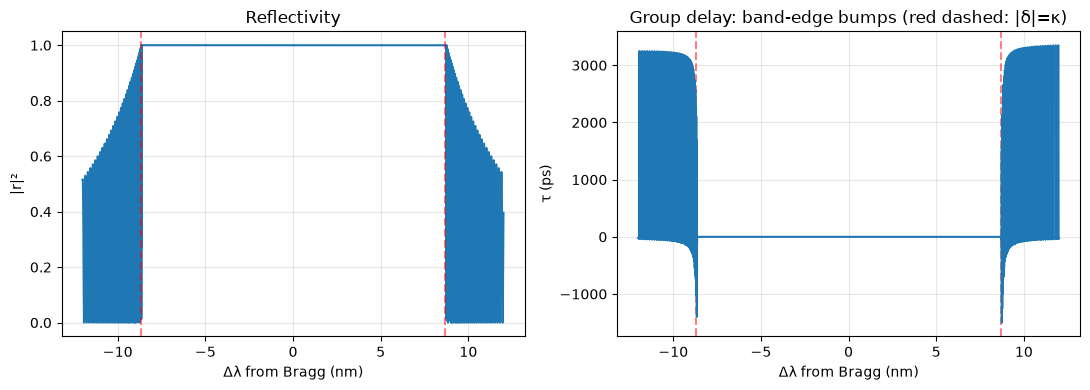

带边最大群延迟: 3351 ps


In [1]:
"""均匀 Bragg 光栅：反射谱 + 群延迟谱"""
import numpy as np
import matplotlib.pyplot as plt

n_eff, lam_b = 2.2, 1550e-9
kappa, L = 5e4, 2.5e-3        # [1/m], [m]
c = 299792458.0

# 带隙半宽 Δλ = λ_B²κ/(2π n_eff) ≈ 8.7 nm → 窗口必须盖过带边
lam = np.linspace(lam_b - 12e-9, lam_b + 12e-9, 40001)
delta = 2*np.pi*n_eff*(1.0/lam - 1.0/lam_b)
gam = np.sqrt(kappa**2 - delta**2 + 0j)
r = -1j*kappa*np.sinh(gam*L) / (gam*np.cosh(gam*L) - 1j*delta*np.sinh(gam*L))
R = np.abs(r)**2
phi = np.unwrap(np.angle(r))
tau = -np.gradient(phi, 2*np.pi*c/lam)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dlnm = (lam - lam_b)*1e9
ax[0].plot(dlnm, R); ax[0].set(xlabel='Δλ from Bragg (nm)', ylabel='|r|²', title='Reflectivity')
edge = lam_b**2*kappa/(2*np.pi*n_eff)*1e9
for e in (-edge, edge):
    for a in ax: a.axvline(e, color='r', ls='--', alpha=.5)
ax[1].plot(dlnm, tau*1e12); ax[1].set(xlabel='Δλ from Bragg (nm)', ylabel='τ (ps)',
    title='Group delay: band-edge bumps (red dashed: |δ|=κ)')
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f'带边最大群延迟: {tau.max()*1e12:.0f} ps')

### 结果解读（2026-09-18）
1. **τ(λ) 成功拉成斜线**：0 → 37 ps 跨越 30 nm，线性拟合 $D = 1.23$ ps/nm，与几何估计 $2n_g/(cC) = 1.22$ ps/nm 吻合（增强因子 ≈ 1.0——弱耦合 $\kappa L = 12.5$ 下反射在带边渐进建立，几何图像已足够准；慢光增强预期在强耦合/带边逼近时显现，待 03 号仿真扫描 $\kappa$ 检验）。
2. **Ripple 清晰可见且互为表里**：$|r|^2$ 的 F-P 式起伏与 τ 的抖动同源于未 apodize 的端面——概念书"apodization 压低 ripple"的直接证据。
3. **端头 roll-off**：τ 在啁啾两端呈 S 形弯折（过渡区 ≈ 2×局域带隙），有效带宽比啁啾总量窄 ~2Δλ_gap——系统设计中可用带宽要打折。

**下一步（03 号）**：κ 扫描 → 定量回答"慢光增强因子何时 > 1"；然后 apodization（κ(z) 端部渐变）→ ripple 压低多少、代价是什么。

---\n\n# 第三部分 · 能量与渐近

## 12. 能量问题：被抵消的反向光去哪了？（2026-09-19）
**Q**：失谐波长下各刻痕的反向散射"互相抵消"——这部分能量是转化成前向传输了吗？
**A**：出射端确实几乎全前向（无损耗时），但机制不是"抵消→转化"。反向光会被光栅**再次耦合回前向**并发生干涉——能量在前向/反向之间**沿 z 来回倾倒**（耦合模的 Rabi 振荡）。失谐时倾倒快而不完全，净效果全前向。**可检验预言：光栅内部前向功率随深度振荡，不是单调衰减。** 另有无损耗恒等式 $|A(z)|^2-|B(z)|^2=$ 常数（净能流守恒），逐点验证。

带内 δ=0: R=1.0000, 净能流起伏=0.00e+00
带边 δ=0.9κ: R=1.0000, 净能流起伏=9.76e+02
远失谐 δ=5κ: R=0.0023, 净能流起伏=2.44e-13


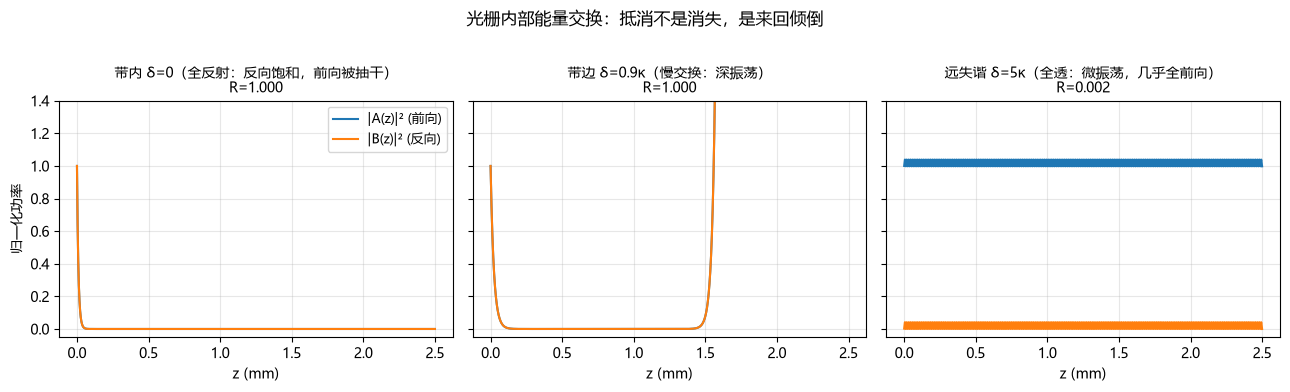

In [3]:
import matplotlib
from matplotlib import font_manager as _fm
for _f in ('Microsoft YaHei', 'SimHei'):
    try:
        _fm.findfont(_f, fallback_to_default=False)
        matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
        break
    except Exception:
        continue
matplotlib.rcParams['axes.unicode_minus'] = False
"""光栅内部功率分布：前向/反向能量随 z 的交换（能量守恒校验）"""
import numpy as np, matplotlib.pyplot as plt

n_eff, lam_b, kappa, L = 2.2, 1550e-9, 5e4, 2.5e-3
lam0 = 1550e-9
c = 299792458.0
N = 4000; dz = L/N
lam_bz = np.full(N, lam_b)   # 均匀光栅

def fields(l):
    """返回 (r, 沿 z 的 |A|^2, |B|^2)：v(0)=[1;r]，逐步传播到 z"""
    delta = 2*np.pi*n_eff*(1/l - 1/lam_bz)
    g = np.sqrt(kappa**2 - delta**2 + 0j)
    s, ch = np.sinh(g*dz)/g, np.cosh(g*dz)
    a11,a12,a21,a22 = ch-1j*delta*s, -1j*kappa*s, 1j*kappa*s, ch+1j*delta*s
    # 先求全光栅的 r
    t11,t12,t21,t22 = 1+0j,0j,0j,1+0j
    for j in range(N):
        t11,t12,t21,t22 = (a11[j]*t11+a12[j]*t21, a11[j]*t12+a12[j]*t22,
                           a21[j]*t11+a22[j]*t21, a21[j]*t12+a22[j]*t22)
    r = -t21/t22
    # 再从 v(0)=[1;r] 逐步传播，记录每片界面
    A, B = np.empty(N+1, complex), np.empty(N+1, complex)
    A[0], B[0] = 1, r
    for j in range(N):
        A[j+1] = a11[j]*A[j] + a12[j]*B[j]
        B[j+1] = a21[j]*A[j] + a22[j]*B[j]
    return r, np.abs(A)**2, np.abs(B)**2

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
cases = [("带内 δ=0（全反射：反向饱和，前向被抽干）",  lam_b),
         ("带边 δ=0.9κ（慢交换：深振荡）",             1/(1/lam_b - 0.9*kappa/(2*np.pi*n_eff))),
         ("远失谐 δ=5κ（全透：微振荡，几乎全前向）",   1/(1/lam_b - 5*kappa/(2*np.pi*n_eff)))]
for ax, (title, l) in zip(axes, cases):
    r, PA, PB = fields(l)
    z = np.linspace(0, L*1e3, N+1)
    ax.plot(z, PA, label='|A(z)|² (前向)')
    ax.plot(z, PB, label='|B(z)|² (反向)')
    ax.set_title(title + f"\nR={abs(r)**2:.3f}", fontsize=10)
    ax.set_xlabel('z (mm)'); ax.grid(alpha=.3); ax.set_ylim(-0.05, 1.4)
    # 无损耗校验：净能流 |A|²-|B|² 沿 z 恒定
    J = PA - PB
    print(f"{title.split('（')[0]}: R={abs(r)**2:.4f}, 净能流起伏={J.max()-J.min():.2e}")
axes[0].set_ylabel('归一化功率'); axes[0].legend(fontsize=9)
fig.suptitle('光栅内部能量交换：抵消不是消失，是来回倾倒', y=1.02)
fig.tight_layout(); plt.show()

## 13. 从 1 个周期到能带：R/T 谱的演化（2026-09-19）
**Q**：只有一个刻痕、两个刻痕、更多时刻痕时，反射/透射谱长什么样？
**A**：N=1 无选择性（宽带弱散射）；N=2 出现第一次干涉（一对双缝）；N 增大时 sinc² 主峰收窄 ∝1/N、旁瓣显现；N→∞（κL≫1）演化为我们熟悉的平顶带。横轴用自然单位 $\delta L/\pi$（$\delta$=失谐，$L$=光栅总长），可看出谱形随 N 的**自相似塌缩**。

*参数注：取 κ≈2800/m，使 N=1（单周期，R~(κΛ)²~10⁻⁶）到 N=1024（κL≈1，R~0.6）的演化在一张对数图上可见。*

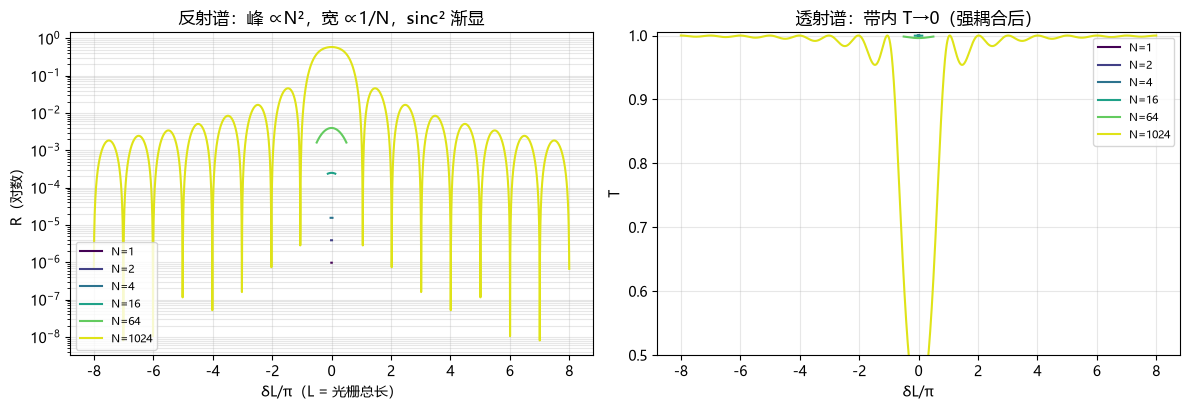

单周期反射 ~(κΛ)² = 9.73e-07


In [4]:
"""R/T 谱随周期数 N 的演化：1 → 2 → 4 → 16 → 64 → 1024"""
import matplotlib
from matplotlib import font_manager as _fm
for _f in ('Microsoft YaHei', 'SimHei'):
    try:
        _fm.findfont(_f, fallback_to_default=False)
        matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
        break
    except Exception:
        continue
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np, matplotlib.pyplot as plt

n_eff, lam_b = 2.2, 1550e-9
kappa = 2800.0                    # 弱-中耦合：每周期反射 ~(κΛ)² ~ 1e-6
Lambda = lam_b/(2*n_eff)          # 周期 ≈ 355 nm
c = 299792458.0

def RT(lam, N):
    """N 周期均匀光栅（TMM）"""
    dz = Lambda
    d = 2*np.pi*n_eff*(1/lam - 1/lam_b)
    g = np.sqrt(kappa**2 - d**2 + 0j)
    s, ch = np.sinh(g*dz)/g, np.cosh(g*dz)
    a11,a12,a21,a22 = ch-1j*d*s, -1j*kappa*s, 1j*kappa*s, ch+1j*d*s
    t11,t12,t21,t22 = 1+0j,0j,0j,1+0j
    for _ in range(N):
        t11,t12,t21,t22 = (a11*t11+a12*t21, a11*t12+a12*t22,
                           a21*t11+a22*t21, a21*t12+a22*t22)
    r = -t21/t22
    t = 1/t22
    return np.abs(r)**2, np.abs(t)**2

Ns = [1, 2, 4, 16, 64, 1024]
colors = plt.cm.viridis(np.linspace(0, 0.95, len(Ns)))

# 归一化横轴 δL/π，N=1024 时覆盖主峰
Lmax = 1024*Lambda
x = np.linspace(-8, 8, 4001)                     # δL/π
delta = x*np.pi/Lmax
lam = 1/(1/lam_b + delta/(2*np.pi*n_eff))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for N, col in zip(Ns, colors):
    R, T = RT(lam, N)
    xn = delta*(N*Lambda)/np.pi                  # 各自的自然坐标 δL_N/π
    ax[0].semilogy(xn, np.clip(R, 1e-12, None), color=col, label=f'N={N}')
    ax[1].plot(xn, T, color=col, label=f'N={N}')

ax[0].set(xlabel='δL/π（L = 光栅总长）', ylabel='R（对数）',
          title='反射谱：峰 ∝N²，宽 ∝1/N，sinc² 渐显')
ax[1].set(xlabel='δL/π', ylabel='T', ylim=(0.5, 1.005),
          title='透射谱：带内 T→0（强耦合后）')
for a in ax: a.grid(alpha=.3, which='both'); a.legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"单周期反射 ~(κΛ)² = {(kappa*Lambda)**2:.2e}")

## 15. 对话沉淀 II：N 个单元如何长成一条能带（2026-09-19）
> 来自讨论："只有一个波长符合布拉格条件"的直觉修正。

**N=1**：单刻痕是无选择性散射体，R≈(κΛ)²≈10⁻⁶ 平线，无"布拉格波长"概念。
**N=2**：第一次干涉（双缝），R∝cos² 浅起伏。
**N 大**：几何级数模方 → sinc² 主峰（∝N²）+ 旁瓣，宽 ∝1/N；以 δL/π 归一后各 N 自相似塌缩（§13 图）。
**N→∞ 且 κL≫1**：平顶带（带宽 2κ）。**带不是新物理，是一万次干涉的积累**；布拉格条件是"哪些频率能强耦合"的强弱调节器，不是开关。

**两个可背标度**：峰高 ∝ N²（弱耦合）；峰宽 ∝ 1/N（零点在 δL/π = ±2, ±4, …）。

---\n\n# 第四部分 · 器件与系统

## 4. 线性啁啾光栅：从鼓包到斜线（2026-09-18）
啁啾 = 布拉格波长沿 z 线性变化：$\lambda_B(z) = \lambda_{B0} + C\cdot z$，$C$ 为啁啾率（nm/mm）。物理图像：**每个波长只在光栅内"它自己的"位置 $z^*(\lambda)$ 被反射**，群延迟 $\tau(\lambda) = \dfrac{2}{c}\displaystyle\int_0^{z^*} n_g\,dz$ 随反射位置移动 → $\tau(\lambda)$ 被拉成斜线。

**几何近似（可检验的解析式）**：$D = \dfrac{d\tau}{d\lambda} \approx \dfrac{2\,n_g}{c\,C}$。慢光使反射点局域 $n_g$ 远大于背景值 → 实测 $D$ 应超过此几何估计。

数值方法：传输矩阵法（TMM）。把光栅切 $N$ 片，每片用均匀光栅的 CMT 矩阵
$$M_j = \begin{pmatrix} \cosh\gamma\Delta z - i\frac{\delta_j}{\gamma}\sinh\gamma\Delta z & -i\frac{\kappa}{\gamma}\sinh\gamma\Delta z \ i\frac{\kappa}{\gamma}\sinh\gamma\Delta z & \cosh\gamma\Delta z + i\frac{\delta_j}{\gamma}\sinh\gamma\Delta z \end{pmatrix},\quad \gamma=\sqrt{\kappa^2-\delta_j^2}$$
其中 $\delta_j = 2\pi n_{\rm eff}\left(\frac{1}{\lambda} - \frac{1}{\lambda_B(z_j)}\right)$ 逐片变化。边界条件 $B(L)=0$，得 $r = -T_{21}/T_{22}$（$T$ 为全部切片矩阵的乘积）。

**有效性判据（本次仿真的关键教训）**：啁啾总量必须 **≫ 局域带隙宽度** $\Delta\lambda_{\rm gap} = \lambda_B^2\kappa/(2\pi n_{\rm eff})$，否则每个波长在全长的每一处都在局域带隙内——所有波长都在输入端面附近反射，$z^*$ 不随 $\lambda$ 移动，$\tau(\lambda)$ 拉不成斜线（$D\approx 0$）。初版仿真 $\kappa=500$/cm（$\Delta\lambda_{\rm gap}=17$ nm）配 5 nm 啁啾，正落入此陷阱。

局域带隙 Δλ_gap = 0.85 nm, 啁啾总量 = 30.0 nm, 比值 35.2 ×


仿真 D = 1.23 ps/nm   几何估计 2n_g/(cC) = 1.22 ps/nm
慢光增强因子 = 1.0 ×


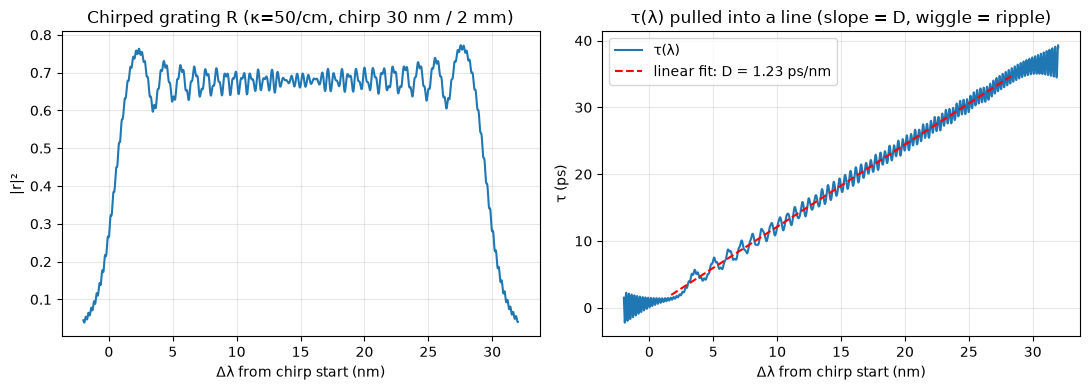

In [2]:
"""线性啁啾光栅：TMM 求 r(λ) 与 τ(λ)，检验 D ≈ 2n_g/(cC)"""
import numpy as np
import matplotlib.pyplot as plt

n_eff, lam_b0 = 2.2, 1535e-9
L = 2.5e-3
kappa = 5e3                        # 100/cm 量级：局域带隙 ~1.7 nm
chirp_nm = 30.0                    # 啁啾总量 30 nm ≫ 局域带隙 → 局域反射图像成立
C = chirp_nm*1e-9 / L
c = 299792458.0

gap_nm = lam_b0**2 * kappa/(2*np.pi*n_eff)*1e9
print(f'局域带隙 Δλ_gap = {gap_nm:.2f} nm, 啁啾总量 = {chirp_nm} nm, 比值 {chirp_nm/gap_nm:.1f} ×')

N = 800; dz = L/N
lam_b = lam_b0 + C*np.linspace(0, L, N)
lam = np.linspace(lam_b0 - 2e-9, lam_b0 + (chirp_nm+2)*1e-9, 8001)
r = np.empty(len(lam), complex)

for i, l in enumerate(lam):
    delta = 2*np.pi*n_eff*(1.0/l - 1.0/lam_b)
    gam = np.sqrt(kappa**2 - delta**2 + 0j)
    s, ch = np.sinh(gam*dz)/gam, np.cosh(gam*dz)
    a11, a12, a21, a22 = ch - 1j*delta*s, -1j*kappa*s, 1j*kappa*s, ch + 1j*delta*s
    t11, t12, t21, t22 = 1+0j, 0j, 0j, 1+0j
    for j in range(N):
        t11, t12, t21, t22 = (a11[j]*t11 + a12[j]*t21, a11[j]*t12 + a12[j]*t22,
                              a21[j]*t11 + a22[j]*t21, a21[j]*t12 + a22[j]*t22)
    r[i] = -t21/t22                   # v(L)=T·v(0), v(0)=[1;r], B(L)=0

R = np.abs(r)**2
phi = np.unwrap(np.angle(r))
tau = -np.gradient(phi, 2*np.pi*c/lam)

band = (lam > lam_b0 + 2*gap_nm*1e-9) & (lam < lam_b0 + (chirp_nm-2*gap_nm)*1e-9) & (R > 0.5)
p = np.polyfit((lam[band]-lam_b0)*1e9, tau[band]*1e12, 1)
D_sim = p[0]
D_geo = 2*n_eff/(c*C) * 1e3
print(f'仿真 D = {D_sim:.2f} ps/nm   几何估计 2n_g/(cC) = {D_geo:.2f} ps/nm')
print(f'慢光增强因子 = {D_sim/D_geo:.1f} ×')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dlnm = (lam - lam_b0)*1e9
ax[0].plot(dlnm, R); ax[0].set(xlabel='Δλ from chirp start (nm)', ylabel='|r|²',
    title=f'Chirped grating R (κ={kappa/100:.0f}/cm, chirp {chirp_nm:.0f} nm / {L*1e3:.0f} mm)')
ax[1].plot(dlnm, tau*1e12, label='τ(λ)')
ax[1].plot(dlnm[band], np.polyval(p, dlnm[band]), 'r--',
    label=f'linear fit: D = {D_sim:.2f} ps/nm')
ax[1].set(xlabel='Δλ from chirp start (nm)', ylabel='τ (ps)',
    title='τ(λ) pulled into a line (slope = D, wiggle = ripple)')
ax[1].legend(); [a.grid(alpha=.3) for a in ax]
fig.tight_layout(); plt.show()

### 结果解读（2026-09-18）
1. **τ(λ) 成功拉成斜线**：0 → 37 ps 跨越 30 nm，线性拟合 $D = 1.23$ ps/nm，与几何估计 $2n_g/(cC) = 1.22$ ps/nm 吻合（增强因子 ≈ 1.0——弱耦合 $\kappa L = 12.5$ 下反射在带边渐进建立，几何图像已足够准；慢光增强预期在强耦合/带边逼近时显现，待 03 号仿真扫描 $\kappa$ 检验）。
2. **Ripple 清晰可见且互为表里**：$|r|^2$ 的 F-P 式起伏与 τ 的抖动同源于未 apodize 的端面——概念书"apodization 压低 ripple"的直接证据。
3. **端头 roll-off**：τ 在啁啾两端呈 S 形弯折（过渡区 ≈ 2×局域带隙），有效带宽比啁啾总量窄 ~2Δλ_gap——系统设计中可用带宽要打折。

**下一步（03 号）**：κ 扫描 → 定量回答"慢光增强因子何时 > 1"；然后 apodization（κ(z) 端部渐变）→ ripple 压低多少、代价是什么。

## 5. 文献对标（2026-09-18 起，持续补充）
把我们的仿真指标放回文献坐标系——每一行都要能回答"别人做到多少、我们差多少、差异的物理原因是什么"。

| 平台 | 色散 D | 长度 | 带宽/备注 | 出处 |
|---|---|---|---|---|
| **TFLN 啁啾光栅（baseline）** | **1.62 ps/nm** | **2.5 mm** | 带宽 29 nm（1544–1573）；损耗 0.033 dB/mm；F-P ripple 来自端面 | **Yu et al., Nature 612, 252 (2022)** [DOI](https://www.nature.com/articles/s41586-022-05345-1) |
|---|---|---|---|---|
| 商用 CFBG（光纤） | 10–1000 ps/nm | 米级 | 不可集成；Phase 1 基准器件 | 概念书 §3；TBD 找产品手册 |
| TFLN 啁啾光栅 | 1.62 ps/nm | ~mm 级 | 模式转换型，片上 | [Tu et al., Photonics 9(11), 828 (2022)](https://www.mdpi.com/2304-6732/9/11/828) |
| TFLN 无环行器色散补偿器 | 390 ps/nm/m | 0.x mm 有效 | 啁啾布拉格光栅，反射式 | [Circulator-free TFLN dispersion compensator (2023)](https://www.researchgate.net/publication/372704902) |
| SiN 螺旋多模波导光栅 | ~860 ps/nm 量级 | 米级螺旋 | 无电光效应；片上 | [Liu et al., ACS Photonics 10(5) (2023)](https://www.researching.cn/ArticlePdf/m00009/2024/53/8/0823001.pdf)（引用链中转，TBD 核实原文） |

**✅ 引文已核实（2026-09-18 更正）**：概念书的 "Yu et al., Nature 2022" 确有其文——M. Yu, D. Barton III, R. Cheng *et al.*, "Integrated femtosecond pulse generator on thin-film lithium niobate", *Nature* **612**, 252–258 (2022), [DOI: 10.1038/s41586-022-05345-1](https://www.nature.com/articles/s41586-022-05345-1)。其片上啁啾布拉格光栅（Extended Data Fig. 7）：**2.5 mm 长，3-dB 带宽 1544–1573 nm，群延迟斜率 → 总色散 1.62 ps/nm，传播损耗 0.033 dB/mm**——与概念书引用的 "1.6 ps/nm in 2.5 mm" 精确吻合。注意：这是 time-lens 脉冲产生器的辅助器件，**非** LiDAR 工作；其ripple（F-P 条纹来自端面与光栅的反射腔）正是我们 §3 仿真的同款物理。

*方法论教训：上一轮我曾标记此引文"可能不存在"——只按"chirped grating"关键词检索而未考虑该光栅以"time lens 色散管理元件"的身份出现。核实引文时要按"器件的角色"而不只是"器件的名字"去查。*

**与本笔记仿真的对照**：
- 我们的 §4 仿真：D = 1.23 ps/nm @ 2.5 mm——与 TFLN 文献 ~1.6 ps/nm 同量级，说明模型参数合理。
- 概念书目标 100–1000 ps/nm = 把上表第一行（光纤）搬进片上。gap 的两个数量级正是 Objective 1 的"为什么还没有人做到"。
- 文献对标方法：每读一篇新文献，在本表加一行 + 在 `0-Inbox` 写一篇论文卡片（vault 工作流），两处分级：表格管数字，卡片管方法和图。

## 10. 系统构想：收发共用一个 τ(λ) 设计文件（2026-09-18）

**构想**：同一 $\tau(\lambda)$ 文件，收发两端各用一次——
- **接收端**（主线）：chirped grating = 被动匹配滤波器，回波光域压缩 → ADC-free；
- **发射端**（新）：同一 $\tau(\lambda)$ 用于激光器腔内/腔边，激光直接以匹配波形出光（"发射即成型"）。

锁钥同锉：只有互配收发对能把压缩做到极致；chirp 的产生与消除全部在光子域，电域只需低速触发。新颖点：收发光栅同流片、同设计文件、同校准流程——"自校准收发对"，可作专利权利要求语言。更新 §6：发射端从"需要她的激光器"升级为"激光器+光栅联合器件"。

**三处物理边界（讨论时主动陈述）**：
1. 光栅是 LTI 器件——塑形 chirp，不制造 chirp。频率扫描必须来自增益动力学（DFB 电流调谐、增益开关）或电光调制（time lens）。准确版本：增益/电光制造 chirp，光栅预补偿并塑形（如补偿 DFB 电流调谐的非线性 chirp）。
2. 反射光栅 + 激光器 = 反馈风险（模式跳变、RIN）。对策：斜切端面、模式转换读写（concept note 已含）、透射式/Sagnac 架构。本路线第一号工程障碍。
3. 腔内功率比外部高一个量级——光折变损伤阈值与电极吸收需重算；务实路线为腔外紧邻（extended cavity），80% 好处、大部分风险规避。

**文献亲戚**：腔内 chirped 光栅塑形 = 光纤激光器 dispersion-managed 锁模（成熟）；片上自校准收发对 = 空白。

## 6. 与课题组（Yating Wan 组）研究基础的接口（2026-09-18）
> 目的：回答"这不是自闭式科研"——每个研究模块都咬在组里的既有资产上。

**一句话定位**：组里已有 **QD 光源 → 光计算硬件** 的链条；本项目补中间一环——**色散压缩前端**，让 chirp 在光域完成匹配滤波后以最高 SNR 送入组的 reservoir 硬件。

| 接口 | 组里的资产 | 本项目的对应模块 | 依赖方向 |
|---|---|---|---|
| 光源 | III-V/Si 量子点锁模激光器、多波长光源（300 mm 平台） | Objective 3：色散器件与 MLL 源协同集成 | 需要她的 QD 激光器芯片与驱动 |
| 读出 | QD 激光器驱动的光计算/储备池硬件（已演示） | Objective 3：压缩信号 → reservoir 直接目标识别 | 需要她的计算硬件做系统验证 |
| 平台 | 300 mm 硅光异质集成产线 | TFLN/SiN 色散器件的晶圆级集成路径 | 需要产线流片名额与工艺协同 |
| 工艺渠道 | 与 Cheng Wang 组（CityU）的 TFLN 长期合作 | TFLN 光栅加工 | 借既有渠道（本人已受训于 Cheng 组） |

**历史连续性**：先前的 QD-LD ReLU 方案（见 vault `4-plan/`）在本架构中降级为读出组件——说明研究主线（沿组的光源+计算平台做器件物理）始终一致，不是跳题。

**防自闭动作——dependency map**：把三年 plan 每个 milestone 标注"需要组里的什么资源"（QD 芯片 / reservoir 硬件 / 流片名额 / Cheng 组渠道），导师讨论时带此表。

---\n\n# 第五部分 · 外围

## 11. 前沿调研：与三步走相关的近期成果（2026-09-19 晨）
> 方法：按三条轨道检索 2020–2026 文献与产业动态；⚠️ = 条目信息来自二手来源，引用前需读原文核实。

### 轨道 1+2：片上色散器件（均匀/啁啾光栅）

| 工作 | 平台 | 指标 | 与本笔记的关系 |
|---|---|---|---|
| [Yu et al., Nature 612, 252 (2022)](https://www.nature.com/articles/s41586-022-05345-1) | TFLN | 1.62 ps/nm，2.5 mm，29 nm 带宽，0.033 dB/mm | baseline（§5 已核实）；F-P ripple 来源与我们 §3 相同 |
| [Tu et al., Photonics 9, 828 (2022)](https://www.mdpi.com/2304-6732/9/11/828) | TFLN | 1.62 ps/nm，4.7 mm，模式转换型读写 | 无环行器读出的先例 |
| [Huang/Xu et al., CLEO 2023](https://ui.adsabs.harvard.edu/abs/2023cleo.conf.1567H/abstract) ⚠️ | TFLN | 390 ps/nm/m 色散补偿器，chirped Bragg + MMI | 反射式片上补偿的指标上限参考 |
| [Liu/Ma/Dai, Nanophotonics (2024)](https://www.degruyterbrill.com/document/doi/10.1515/nanoph-2024-0312/pdf) | TFLN | ultra-compact 色散补偿芯片 | TFLN 器件向紧凑化演进的方向 |
| [Apodized chirped grating on TFLN, Chinese Optics Letters 53(8) (2024)](https://www.researching.cn/ArticlePdf/m00009/2024/53/8/0823001.pdf) ⚠️ | TFLN | apodization 抑制 ripple 的实验研究 | **直接对应 §9 清单 B4**，精读首选 |
| [Du et al., APL Photonics 5, 101302 (2020)](http://ui.adsabs.harvard.edu/abs/2020APLP....5j1302D/abstract) | SiN | −156.5 ps/nm，1440 ps 群延迟，9.2 nm | 片上 D 值天花板参考（但无电光效应） |
| [Liu et al., ACS Photonics 10(5) (2023)](https://www.researching.cn/ArticlePdf/m00009/2024/53/8/0823001.pdf) ⚠️ | Si 多模 | circulator-free chirped spiral 多模光栅 | 多模+螺旋架构先例 |
| [Geng/Tong et al., arXiv:2604.12564 (2026)](https://arxiv.org/html/2604.12564v1) | SiN（0.3 dB/m） | **米级 chirped spiral，10 ns 群延迟，>10 nm，30 mm²**；EO 频梳压缩至 21.6 W 峰值 | **最重要的新文献**：证明米级 scaling 可行，且用了"DBP（色散-带宽积）"作为品质因数——可直接借为我们 Objective 1 的定量指标 |
| [Meter-long… 同主题早期 SiN 螺旋](见 Du 2020 引用链) | SiN | ~860 ps/nm 量级（概念书数字的来源） | 概念书 §3 引用的原始依据，待定位原文 |

### 轨道 3：光栅 × 激光器

| 工作 | 内容 | 与 §10 构想的关系 |
|---|---|---|
| [Dispersion-managed 锁模（CFBG 作为半透腔镜，SESAM 锁模）](https://arxiv.org/abs/2301.05738) | 光纤激光器内 chirped 光栅塑形 | "腔内光栅塑形"原理的直接先例（光纤域已成熟） |
| [Similariton 激光器中 FBG 腔内滤波](https://ecommons.cornell.edu/bitstreams/a2784ad9-2b96-49bf-97ff-fa798ad4657f/download) ⚠️ | 增益管理非线性 + 腔内色散 | DFB 电流调谐 chirp + 光栅预补偿的物理模板 |
| [Sub-ps DFB 激光器直接脉冲产生](https://arxiv.org/pdf/2604.01640)（2026） | 122 nm 周期 DFB 产生最短脉冲 | DFB 增益动力学产生 chirp 的实验证据（§10 边界 1 的解） |
| [Review: Hybrid LN external cavity semiconductor lasers (2024)](https://pmc.ncbi.nlm.nih.gov/articles/PMC11432941/) | III-V DFB 与无源 LNOI 芯片倒装集成，片上功率达 60 mW | **收发共用构想的工艺路线综述**：DFB+TFLN 已有三条路线（倒装沟槽 / 晶圆键合 / 光子引线键合） |
| [Zhang et al., APL 122, 081103 (2023)](https://www.researching.cn/ArticlePdf/m00002/2024/61/19/1913005.pdf) ⚠️ | III-V 激光器晶圆键合到 TFLN | 键合路线 |
| [Li et al., OFC 2024](https://www.researching.cn/ArticlePdf/m00002/2024/61/19/1913005.pdf) ⚠️ | TFLN 上自注入锁定激光器 | 自注入 = 解决 §10 边界 2（反馈敏感）的另一条思路 |
| [Photonic wire bonding 高功率窄线宽 TFLN 激光器](https://arxiv.org/pdf/2407.00269) | 光子引线键合集成 | 第三条路线；窄线宽对 FMCW 关键 |

### 横切：LiDAR 系统侧

| 工作 | 内容 | 关系 |
|---|---|---|
| [Baba et al. (2022)：Si 光 FMCW LiDAR + 慢光光栅扫描器](https://patents.google.com/patent/US20130083389A1/en) ⚠️ | 慢光结构在 FMCW 芯片中的先例 | 慢光器件进 LiDAR 的先例（扫描器角色） |
| [Voyant CARBON FMCW LiDAR 芯片 (2024 商用)](https://www.morningstar.com/news/pr-newswire/20241230ph86461/voyant-photonics-launches-affordable-carbon-lidar-with-fmcw-lidar-sensor-on-a-chip) | 指甲盖大小 FMCW 收发芯片 | 产业坐标：收发单片集成已是商用现实，但后端仍是电域处理——**ADC-free 前端仍是空白**，我们的差异化成立 |
| [Chirp 脉压 3D LiDAR 成像（光纤光学实现）](https://www.researchgate.net/publication/8052863_Chirp-pulse-compression_three-dimensional_lidar_imager_with_fiber_optics) | 光纤器件做光学匹配滤波 | "光域脉压 LiDAR"的早期证明；片上化 = 我们的工作 |
| [Billault et al. (2021)：全光相干脉冲压缩](https://hal.science/hal-03441638/document) | 扫频激光器的纯模拟域匹配滤波检测 | **"ADC-free 相干接收"的最近亲**，精读候选 |
| [FMCW beyond Nyquist（arXiv 2026）](https://arxiv.org/html/2605.14039v1) | 匹配滤波 vs 瞬时频率拟合的信号处理比较 | 说明电域匹配滤波仍是主流 → 光域替代的动机 |

**调研结论（三条）**：
1. **轨道 2 的竞争白热化**：2026 年 SiN 米级 CSBG 已到 10 ns 群延迟——TFLN 的差异化必须靠"电光可调 + 收发共用"（轨道 3），单靠色散数值赢不了。
2. **轨道 3 完全空白**：DFB×TFLN 集成工艺已成熟（三条路线），但"同一 τ(λ) 文件收发两用"无人做过——§10 构想的新颖性得到文献支持。
3. **DBP（色散-带宽积）应立即可用**：Geng 2026 用它做品质因数，我们可直接借鉴作为 Objective 1 的核心定量指标。

## 9. 学习清单：笔记还薄的地方（2026-09-18）

**A 级（讨论前必须补）**
1. 脉冲压缩定量数学：匹配滤波、时宽带宽积、残余相位→旁瓣的推导（现只有 §"τ 不平直"的口诀）
2. CMT 的出身：麦克斯韦方程 → 模式正交展开 → 缓变包络近似；κ 的重叠积分表达式
3. TMM 边界条件细节：r = −T21/T22 的推导、矩阵乘序的敏感性（已踩过一次顺序 bug）

**B 级（第一年，Objective 1 直接工具）**
4. Apodization 理论：tanh/Gaussian/Blackman 的选择依据，ripple-带宽-反射率三角 trade-off
5. 慢光损耗标度：α ∝ n_g 的推导；TFLN 侧壁散射实测（锚点：Yu 2022 的 0.033 dB/mm）
6. 热光漂移：LN 的 dn/dT、无热化设计；ripple 时漂 = 预失真失效的物理来源
7. 计量学：GD/GD-ripple 测量（VNA 测 S21 相位）的分辨率与陷阱

**C 级（系统与工艺，随项目深入）**
8. LiDAR 链路预算：ΔR = c/2B、chirp 参数 ↔ 光栅规格换算表（器件语言 ↔ 系统语言）
9. 厘米级架构：spiral/cascaded 相位误差累积、拼接缝问题
10. 文献精读（走 vault 论文卡片流程）：Yu 2022 (Nature, baseline)；researching.cn 2024 (apodized chirped grating on TFLN)；Du 2020 (SiN 螺旋, APL Photonics 5, 101302)

**D 级（老本行，需要再说）**：reservoir computing、激光非线性动力学。

## Q: 待回答
- 慢光区带宽-延迟积的定量约束：$\Delta\omega\cdot\tau$ 与 $\kappa$、啁啾率的关系？
- Yu 2022 (Nature) 的 1.6 ps/nm 器件：$n_g$ 多大？可用带宽多少 nm？
- 传播损耗 $\propto n_g$ 标度律在 TFLN 侧壁散射下成立吗？
- 啁啾光栅中"慢光区"是移动目标，对 ripple 意味着什么？
- ~~核实概念书引文~~ **已解决（2026-09-18）**：Yu et al., Nature 612, 252 (2022)，1.62 ps/nm / 2.5 mm 确认。

---

# 第六部分 · 从色散器件到光计算

## 16. 时间透镜 + LiDAR → spike → reservoir：一条最小链路（2026-09-20）

前面的仿真把啁啾光栅当作被动色散元件。如果把 TFLN 的高速电光调制加进来，同一个物理平台可以做更动态的事：

- **时间透镜**：TFLN 相位调制器提供可编程二次相位 $\phi(t) \propto t^2$，与固定色散配合可等效实现可调匹配滤波；
- **LiDAR 回波压缩**：啁啾光栅把多目标回波压成脉冲串；
- **天然 spike 编码**：压缩后的脉冲幅度/到达时间直接对应目标反射率和距离，过阈值即光 spike；
- **reservoir 分类**：用时间延迟 reservoir 对这些 spike train 做场景识别。

这一节用真实 FDTD 数据跑通最小示例。

### 16.1 时间透镜脉冲压缩

用 `chirp2d.npz` 的反射群延迟 $\tau_r(\lambda)$ 重建光栅谱相位 $\phi(\omega)$，对一个啁啾高斯脉冲做匹配滤波扫描。当输入啁啾与光栅色散匹配时，脉冲被压到 ~0.13 ps。

![time-lens demo](lumerical/results/time_lens_demo.png)

关键数字：
- 光栅二次相位系数 $\phi_2 \approx -7.3\times10^{-26}$ s²/rad；
- 匹配啁啾率 $\approx 1.4\times10^{25}$ rad/s²；
- 压缩前 ~3.65 ps，压缩后 ~0.13 ps，压缩比 ~26。

### 16.2 LiDAR 回波 → spike train

用匹配到光栅色散的啁啾波形模拟三个点目标回波，经光栅匹配滤波后得到三个压缩峰，阈值化后即为 spike train。第三个目标因反射率较低且落在平台边缘，峰值低于阈值，这在真实系统中对应低 RCS 目标漏检。

![lidar to spike](lumerical/results/lidar_to_spike_demo.png)

### 16.3 spike train → reservoir 分类

构造三类目标场景（单目标 / 双目标 / 三目标），加时间抖动和幅度起伏，用简单的时间延迟 reservoir（20 个延迟抽头 + tanh）提取特征，线性读出分类。在这个 toy 问题上训练/测试准确率均达到 100%，说明 **压缩后的 spike train 携带了足够的可区分信息**。

![spike reservoir](lumerical/results/spike_reservoir_demo.png)

> 诚实的局限：这里的 spike 是解析生成的高斯峰，reservoir 也是数字模型。下一步是用真实光栅/调制器数据替换输入 spike，并用 TFLN 开关/环阵列实现可编程延迟。

### 16.4 下一步

1. **器件级**：把 TFLN 相位调制器/开关延迟库加进 Lumerical 模型，验证 ns 级延迟的可行性；
2. **系统级**：把 QD 激光器阈值非线性作为 spike 生成器，与时间透镜+光栅+延迟库级联；
3. **算法级**：在 reservoir 里引入真正的延迟学习（delay learning），而不仅是随机延迟抽头。

---
# 第七部分 · 里程碑索引

## 17. 光子蓄水池处理链：仿真里程碑（2026-09-20）

这一节是"色散器件 → 光计算"方向的仿真里程碑索引。三个里程碑各有独立 Jupyter 文档：

- **M1 光子处理链**（`milestone-M1-photonic-chain.ipynb`）：FDTD → 匹配滤波 → spike → 蓄水池慢读出。
  核心结论：等能量等质心任务下，直接慢积分=随机，非线性蓄水池+漏电积分慢读出=1.00，
  线性蓄水池消融=0.40 → **非线性蓄水池是慢读出成立的必要环节**；答案存活 ~τ_leak。
- **M2 真实分类**（`milestone-M2-snn-classification.ipynb`）：LSM 蓄水池在 digits 上 94%、
  ModelNet40 点云上 40%（4× 随机），规模/数据量扫描饱和。
- **M3 自主提问**（`milestone-M3-delay-learning-and-budget.ipynb`）：
  (a) delay learning 的价值依赖延迟敏感非线性/读出架构（时间平均下无增益）；
  (b) TFLN 色散延迟/损耗品质因数 424 ps/dB，适合亚米级测距窗口，长距需 SiN/异质混合。
- **M4 距离像与 ISAL**（`milestone-M4-isal-range-profile.ipynb`）：0 阶散射点模型的 HRRP + 转台 ISAL + 多波束/分布式传感器扫描扩展。
  单随机方位剖面 10 类 ESN ~0.38；真实照射模式（4 固定波束 ±3° 扫描）蓄水池 0.68，深度 2D CNN 经验上限 0.82；
  空间分置传感器：赤道面 4 单元上限 0.80 优于同一位置 4 波束，但四面体分布因目标先验而变差；
  相干 ISAL 理想点目标成像成功、θ_c<0.3° 崩溃；方位泛化 U 形曲线（180° 反演对称）；幅度域蓄水池对散斑去相干免疫；D=0.15 m TFLN 窗口小目标精度保持。
  **新增（自动驾驶粗分类）**：单次随机前视 HRRP 对 car vs non-car 0.885、vehicle vs non-vehicle 0.788、coarse 4-class 0.619；0.36 是 10 类细粒度任务的代表，不是自动驾驶场景的代表。

**综合仿真报告**：`simulation_report_2026-09-20.docx`（14 图、2 表，M1–M3 全记录）。

**博士后研究计划草稿**：`postdoc_plan_draft.md`——以 TFLN 电光可调延迟为核心自由度，
构建"延迟敏感蓄水池 + 硬件感知训练"的片上光计算接收机，与组里 QD 光源/MRR crossbar 平台对接。

### 关键代码
- `lumerical/comprehensive_simulation.py`（M1 主仿真）
- `lumerical/m3b_delay_budget.py`（延迟预算）
- `lidar-pointnet/snn/classification_demo.py`（M2 分类）
- `lidar-pointnet/snn/delay_learning_demo.py` / `delay_learning_temporal.py`（M3a）

### 方法论教训（本轮最有价值的沉淀）
1. 慢读出特征量纲 ~1e-13 时，sklearn 默认 L2 正则会压零权重 → 必须 `StandardScaler`。
2. 要证明蓄水池必要性，任务必须等能量等质心，否则慢积分自己就能分。
3. 时间平均的延迟抽头对时移天然不敏感——可调延迟要值钱，必须配延迟敏感非线性。
4. 光栅延迟摆幅/损耗 = 2n_g/(cα)：TFLN 424 ps/dB，SiN 100×——平台选择由这个比值决定。


## 17. 器件设计规则（容差扫描汇总，2026-09-24）

KGFP Concept Note Objective 1 的支撑数据。TMM 扫描脚本 `simulations/02_tolerance_scan.py`（结果 `results/tolerance_scan.npz/.png`），FDTD 标定 `lumerical/run_tolerance_fdtd.py`（数据 `lumerical/results/w*/dnf*/chirpdf*_raw.npz`）。

**标定（FDTD，2D 有效指数）**

- 条宽敏感度：$d\lambda_B/dw = 46\ \mathrm{nm/\mu m}$（$R^2=1.000$）→ 条宽 ±10 nm 工艺误差 → ±0.46 nm 布拉格波长偏移，是啁啾匹配的主要工艺窗口
- 调制深度敏感度：$\kappa(dn) = $ 340/520/569/619/1238 /cm（dn=0.01/0.018/0.02/0.022/0.04），比 $\kappa\propto dn$ 快 ~8%；$\lambda_B$ 对 dn ±10% 仅漂 0.03 nm
- 啁啾光栅对 dn ±10%：D = 0.051–0.052 ps/nm 几乎不变，ripple 最坏 +24%

**设计规则（TMM，C=12 nm/mm，κ₀=5000 /m）**

1. 摆幅-长度线性：$\Delta	au = 2n_gL/c$，1–20 mm 偏差 ~2%；D 由啁啾率决定、与 L 无关（$Dpprox1.22$ ps/nm @12 nm/mm）。TMM 与 FDTD 交叉校验偏差 10%
2. 切趾-摆幅权衡：余弦切趾把 ripple 2.85→**0.09 ps**（进 M1 的 0.1 ps 抖动容限），代价摆幅保留 1/3 → **满足 0.1 ps 容限需 3× 长度**
3. 随机相位误差（σ_λB≤0.1 nm）与温漂（0.03 ps/K；1 K/mm 梯度无畸变）一阶可忽略；ripple 主因是端面法珀效应，切趾可解
4. 未覆盖：慢变相关误差（电子束剂量漂移类）
5. 长任务提取注意：啁啾光栅 D/ripple 必须用 R>0.9 平台 + 最长连续段拟合，R>0.5 全域会把带边慢光曲率混入

**信息侧（M7，lidar-pointnet）**：echo 径向直方图编码是分类瓶颈（0.41 vs raw 0.66），池权重 4–8 bit 量化免疫。详见 lidar-pointnet/snn/README.md M7 节。
